#Momentum Portfolio Construction and Evaluation

Using the momentum decile assignments, this notebook:
1. Computes the **cumulative return** of each decile portfolio (Jan 2021 – Jan 2026, equal-weighted monthly rebalancing).
2. Plots all 10 cumulative return series on a **log-scale** chart.
3. Reports the **annualized Sharpe ratio** of each decile (risk-free rate = 0).
4. Evaluates the **long-short portfolio** (Decile 10 − Decile 1): annualized mean return and Sharpe ratio.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)

# ── Load the enriched monthly panel ────────────────────────

DATA_PATH = 'monthly_stock_ma_data.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df.sort_values(['ticker', 'date'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Rows:    {len(df):,}')
print(f'Tickers: {df["ticker"].nunique():,}')
print(f'Dates:   {df["date"].min().date()}  to  {df["date"].max().date()}')
print(f'Columns: {list(df.columns)}')

Rows:    220,535
Tickers: 5,584
Dates:   2021-01-06  to  2026-01-30
Columns: ['ticker', 'date', 'close', 'closeadj', 'MA_3', 'MA_12', 'MA_ratio', 'golden_cross', 'ret', 'fwd_ret', 'momentum', 'lagged_ret', 'marketcap', 'sector', 'industry']


## Step 1 – Assign Momentum Deciles and Compute Monthly Decile Returns

Each month, stocks are sorted into 10 equal groups (deciles) based on their **momentum** signal.  
Within each decile the portfolio return is the **equal-weighted average** of `fwd_ret`.

In [ ]:
# Keep rows where both momentum and fwd_ret are available
data = df.dropna(subset=['momentum', 'fwd_ret']).copy()

# Assign decile each month (1 = lowest momentum, 10 = highest)
def assign_decile(series):
    return pd.qcut(series, q=10, labels=False, duplicates='drop') + 1

data['decile'] = data.groupby('date')['momentum'].transform(assign_decile)
data = data.dropna(subset=['decile'])
data['decile'] = data['decile'].astype(int)

# Equal-weighted monthly return per decile
monthly_ret = (
    data.groupby(['date', 'decile'])['fwd_ret']
    .mean()
    .reset_index()
    .rename(columns={'fwd_ret': 'ret'})
)

# Pivot: rows = date, columns = decile
ret_pivot = monthly_ret.pivot(index='date', columns='decile', values='ret').sort_index()

print('Monthly decile returns (first 5 rows):')
print(ret_pivot.head())

Monthly decile returns (first 5 rows):
decile          1      2      3      4      5      6      7      8      9   \
date                                                                         
2021-01-29  0.1511 0.1211 0.1072 0.0846 0.0792 0.0754 0.0652 0.0497 0.0602   
2021-02-26  0.0163 0.0413 0.0474 0.0600 0.0433 0.0380 0.0466 0.0118 0.0087   
2021-03-31  0.0017 0.0205 0.0406 0.0327 0.0301 0.0292 0.0333 0.0206 0.0532   
2021-04-30 -0.0066 0.0240 0.0132 0.0141 0.0263 0.0214 0.0021 0.0160 0.0211   
2021-05-28  0.0540 0.0164 0.0176 0.0096 0.0071 0.0016 0.0098 0.0172 0.0382   

decile          10  
date                
2021-01-29  0.0386  
2021-02-26 -0.0319  
2021-03-31 -0.0152  
2021-04-30  0.0168  
2021-05-28  0.0740  


## Step 2 – Cumulative Returns (Jan 2021 – Jan 2026)

In [ ]:
# Restrict to the specified window
start = '2021-01-01'
end   = '2026-01-31'
ret_window = ret_pivot.loc[start:end].copy()

# Cumulative return: start at 1.0
cum_ret = (1 + ret_window).cumprod()

print(f'Window: {ret_window.index.min().date()} to {ret_window.index.max().date()}')
print(f'Months: {len(ret_window)}')
print('\nTerminal cumulative return by decile:')
print(cum_ret.iloc[-1].rename('Cumulative Return').to_frame())

Window: 2021-01-29 to 2025-12-31
Months: 60

Terminal cumulative return by decile:
        Cumulative Return
decile                   
1                  0.7668
2                  1.5921
3                  1.7006
4                  1.4444
5                  1.7427
6                  1.8900
7                  1.5738
8                  1.6579
9                  1.9708
10                 1.9996


## Step 3 – Plot Cumulative Returns (Log Scale)

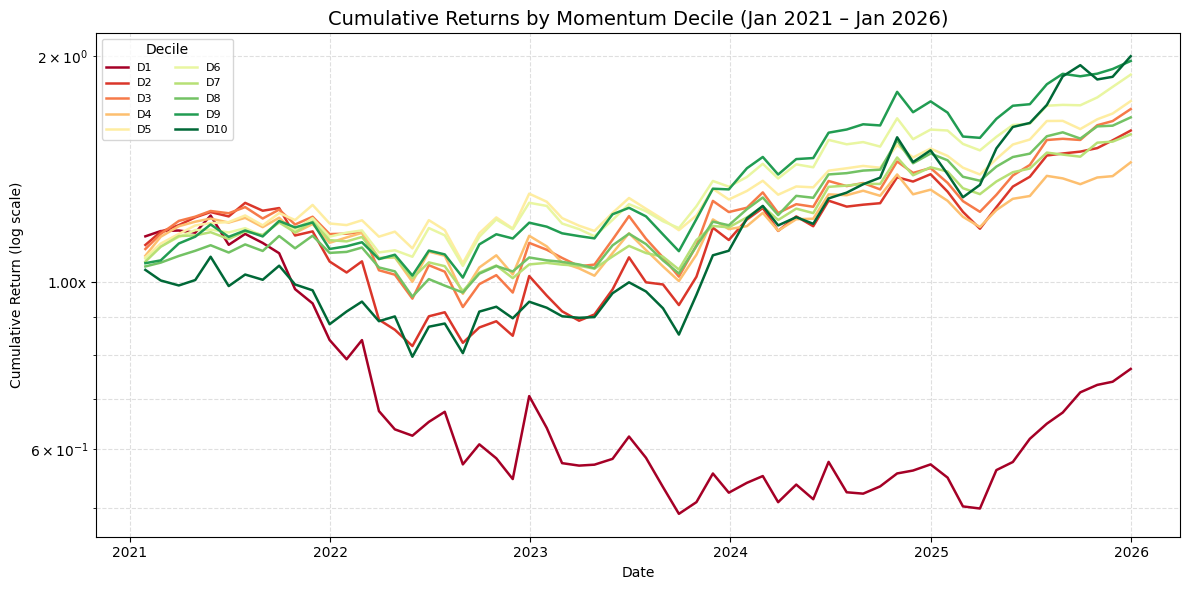

Chart saved as momentum_cumulative_returns.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

cmap = plt.cm.RdYlGn
colors = [cmap(i / 9) for i in range(10)]

for dec in range(1, 11):
    if dec in cum_ret.columns:
        ax.plot(
            cum_ret.index, cum_ret[dec],
            color=colors[dec - 1],
            linewidth=1.8,
            label=f'D{dec}'
        )

ax.set_yscale('log')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f'{y:.2f}x'))
ax.set_title('Cumulative Returns by Momentum Decile (Jan 2021 – Jan 2026)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (log scale)')
ax.legend(title='Decile', ncol=2, fontsize=8)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('momentum_cumulative_returns.png', dpi=150)
plt.show()
print('Chart saved as momentum_cumulative_returns.png')

## Step 4 – Annualized Sharpe Ratio by Decile

With monthly returns and a risk-free rate of zero:

$$\text{Sharpe} = \frac{\bar{r}_{\text{monthly}}}{\sigma_{\text{monthly}}} \times \sqrt{12}$$

In [ ]:
mean_monthly  = ret_window.mean()
std_monthly   = ret_window.std()
ann_mean      = mean_monthly * 12
ann_sharpe    = (mean_monthly / std_monthly) * np.sqrt(12)

summary = pd.DataFrame({
    'Ann. Mean Return': ann_mean,
    'Ann. Volatility':  std_monthly * np.sqrt(12),
    'Ann. Sharpe Ratio': ann_sharpe
})
summary.index.name = 'Decile'
print(summary.to_string())

        Ann. Mean Return  Ann. Volatility  Ann. Sharpe Ratio
Decile                                                      
1                -0.0176           0.2706            -0.0650
2                 0.1175           0.2233             0.5263
3                 0.1260           0.2004             0.6287
4                 0.0890           0.1772             0.5025
5                 0.1227           0.1509             0.8127
6                 0.1390           0.1505             0.9236
7                 0.0994           0.1305             0.7613
8                 0.1109           0.1389             0.7985
9                 0.1491           0.1616             0.9229
10                0.1621           0.2160             0.7502


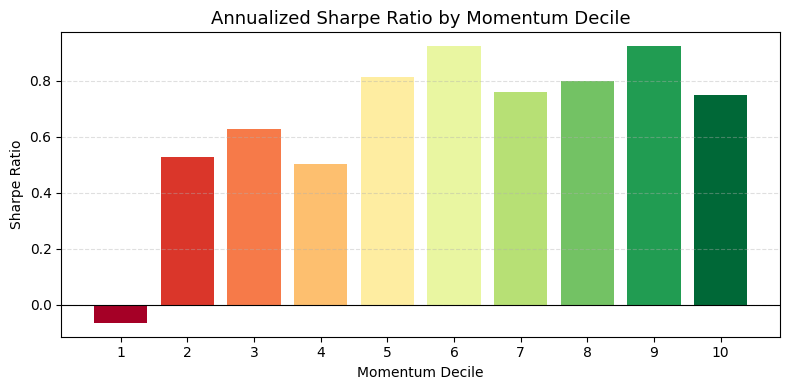

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = [plt.cm.RdYlGn(i / 9) for i in range(10)]
ax.bar(summary.index, summary['Ann. Sharpe Ratio'], color=colors_bar)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Annualized Sharpe Ratio by Momentum Decile', fontsize=13)
ax.set_xlabel('Momentum Decile')
ax.set_ylabel('Sharpe Ratio')
ax.set_xticks(range(1, 11))
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('momentum_sharpe_by_decile.png', dpi=150)
plt.show()

## Step 5 – Long-Short Portfolio (Decile 10 − Decile 1)

The long-short (LS) portfolio goes **long** the highest-momentum decile (D10) and **short** the lowest (D1), rebalanced monthly.

In [ ]:
ls_ret = ret_window[10] - ret_window[1]

ls_mean_monthly  = ls_ret.mean()
ls_std_monthly   = ls_ret.std()
ls_ann_mean      = ls_mean_monthly * 12
ls_ann_sharpe    = (ls_mean_monthly / ls_std_monthly) * np.sqrt(12)

ls_cum = (1 + ls_ret).cumprod()

print('Long-Short Portfolio (D10 − D1)')
print(f'  Annualized Mean Return : {ls_ann_mean:.4f}  ({ls_ann_mean*100:.2f}%)')
print(f'  Annualized Sharpe Ratio: {ls_ann_sharpe:.4f}')
print(f'  Terminal Cumulative Return: {ls_cum.iloc[-1]:.4f}x')

Long-Short Portfolio (D10 − D1)
  Annualized Mean Return : 0.1796  (17.96%)
  Annualized Sharpe Ratio: 0.8562
  Terminal Cumulative Return: 2.1809x


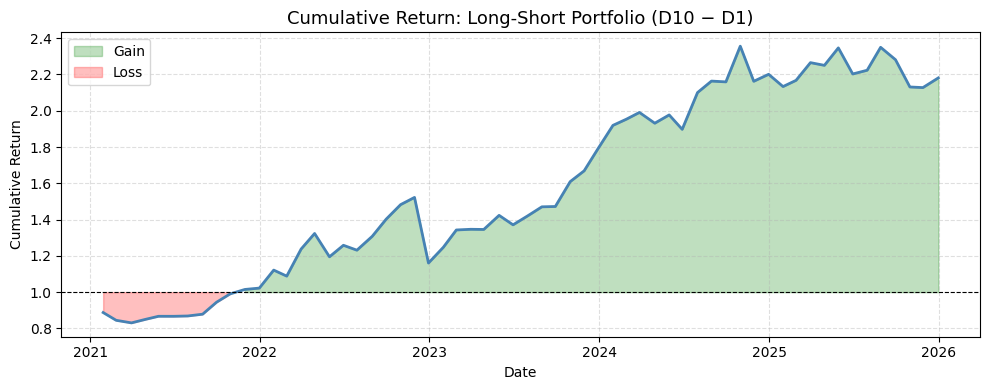

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ls_cum.index, ls_cum.values, color='steelblue', linewidth=2)
ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--')
ax.fill_between(ls_cum.index, 1.0, ls_cum.values,
                where=(ls_cum.values >= 1.0), alpha=0.25, color='green', label='Gain')
ax.fill_between(ls_cum.index, 1.0, ls_cum.values,
                where=(ls_cum.values < 1.0),  alpha=0.25, color='red',   label='Loss')
ax.set_title('Cumulative Return: Long-Short Portfolio (D10 − D1)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('momentum_long_short_cumret.png', dpi=150)
plt.show()

## Discussion

### Cumulative Returns Across Deciles
The log-scale plot reveals whether the momentum effect generates a spread in realized wealth across deciles over the Jan 2021–Jan 2026 window. A classic momentum premium would show Decile 10 outperforming Decile 1, with a roughly monotone ordering from bottom to top decile. Divergence or reversals — particularly if low-momentum stocks outperform — would suggest the momentum signal is weak or that mean-reversion dominates in this sample.

### Sharpe Ratios
The Sharpe ratio controls for the volatility embedded in each decile's return stream. Higher-momentum stocks tend to exhibit higher volatility, so the risk-adjusted view can look materially different from the raw-return ranking. An increasing Sharpe profile from D1 to D10 would constitute strong evidence for momentum as a risk-adjusted alpha source in this dataset.

### Long-Short Portfolio
The long-short strategy removes broad market exposure and isolates the cross-sectional momentum spread. A positive annualized mean return combined with a Sharpe ratio above ~0.5 is generally considered economically meaningful for a factor portfolio. A negative or near-zero result would indicate that momentum did not reliably predict the cross-section of returns over this five-year window — consistent with the relatively short and bull-market-heavy sample period (2021–2026) where dispersion across stocks may be compressed.